In [ ]:
import numpy as np
import pymc as pm
import matplotlib.pyplot as plt
import arviz as az

## Ejercicio 5: Generar Datos Sintéticos para una Regresión Lineal Simple


Generar datos sintéticos
de una regresión lineal simple con ruido gaussiano, como los que generábamos
cuando veíamos regresión lineal frecuentista. Por ejemplo, considerar la
función $f:\mathbb{R}\rightarrow \mathbb{R}$ dada por $f(x) = 2x - 1$, $X \sim \mathcal{U}(0,1)$ y $Y := f(X)$ y $n = 100$; tomar  muestras $x_1,\ldots,x_{n}$ de $X$ y aplicar lafunción  $f$ a cada muestra para calcular $y_i = f(x_i)$, con $1\leq i \leq n$.

*  a) Ajustar un modelo lineal de la forma $y\sim N(\beta_0+\beta_1 x,\epsilon)$ usando PyMC. Graficar y describir las posterior de los parámetros de la regresión.

* b) ¿Cuál es el valor que estimamos que tenga $f(\frac{1}{2})$? ¿Con qué error?

* c)Graficar y dar percentiles de la distribución de $\beta_0 + \frac{1}{2} \beta_1$.

In [ ]:
n = 100
X = np.random.uniform(0, 1, n)
Y = 2 * X - 1
Y = Y + np.random.normal(0, 0.1, 100)

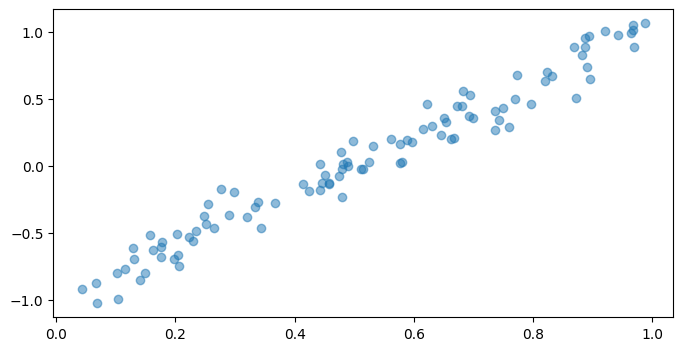

In [ ]:
plt.figure(figsize=(8, 4))
plt.scatter(X, Y, alpha=0.5, label='datos generados')


### a) **Ajustar un modelo lineal de la forma**

**Planteamos un modelo lineal de la forma $y\sim N(\beta_0+\beta_1 x,\epsilon)$**


In [ ]:
with pm.Model() as modelo:
    beta0 = pm.Normal('beta0', mu=0, sigma=10)
    beta1 = pm.Normal('beta1', mu=0, sigma=10)
    sigma = pm.HalfNormal('sigma', sigma=1)

    mu = beta0 + beta1 * X
    Y_obs = pm.Normal('Y_obs', mu=mu, sigma=sigma, observed=Y)
    trace = pm.sample(2000, tune=1000, return_inferencedata=True)

Output()

Output()

### Graficar y describir las posterior de los parámetros de la regresión.

In [ ]:
az.summary(trace)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta0,-1.002,0.024,-1.045,-0.956,0.001,0.000,1670.0,1641.0,1.0
beta1,2.022,0.041,1.947,2.099,0.001,0.001,1675.0,1618.0,1.0
sigma,0.110,0.008,0.096,0.126,0.000,0.000,2374.0,2045.0,1.0


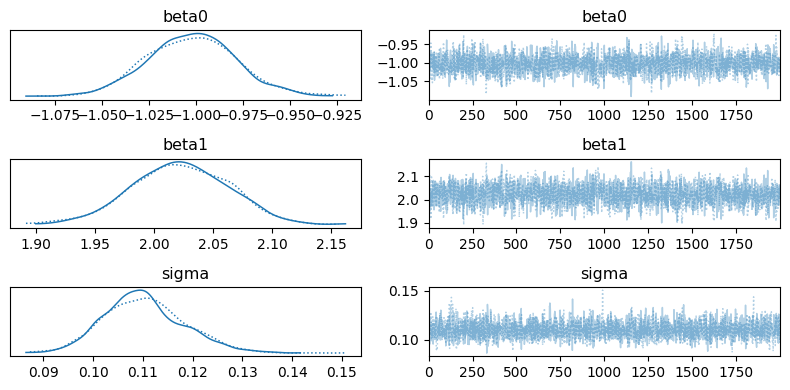

In [ ]:
az.plot_trace(trace,figsize= (8,4))
plt.tight_layout()

In [ ]:
summary = az.summary(trace)
print("\nEstadísticas resumen:")
summary


Estadísticas resumen:


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta0,-0.991,0.018,-1.022,-0.954,0.000,0.000,1690.0,1764.0,1.01
beta1,1.996,0.032,1.939,2.054,0.001,0.001,1669.0,1876.0,1.01
sigma,0.087,0.006,0.076,0.100,0.000,0.000,2131.0,1913.0,1.00


### b) Calcular $f(\frac{1}{2})$
Para calcular $f(\frac{1}{2})$, estamos usando la estimación del modelo de regresión lineal ajustado.

In [ ]:
x = 0.5
posterior_samples = trace.posterior
beta0_samples = posterior_samples['beta0'].values.flatten()
beta1_samples = posterior_samples['beta1'].values.flatten()

In [ ]:
posterior_samples['beta0'].values

array([[-0.98095483, -0.98276444, -0.96465042, ..., -1.00427883,
        -1.000106  , -1.01078009],
       [-0.98632677, -0.98530339, -0.99966467, ..., -0.98252697,
        -0.97975587, -0.99552903]])

In [ ]:
# Calcular f(1/2)
x = 0.5
#tiene las muestras a de las distribuciones posterioes
posterior_samples = trace.posterior
f_medio = posterior_samples['beta0'].values + x * posterior_samples['beta1'].values

#media y el error
valor_medio = float(np.mean(f_medio))
error = float(np.std(f_medio))

print(f"\nPredicción para f(1/2): {valor_medio:.3f} ± {error:.3f}")


Predicción para f(1/2): 0.008 ± 0.009


(array([  1.,   3.,   4.,   6.,  15.,  32.,  46.,  82., 129., 155., 206.,
        281., 313., 367., 413., 356., 346., 328., 268., 206., 153.,  98.,
         78.,  47.,  28.,  20.,   9.,   4.,   2.,   4.]),
 array([-0.02419827, -0.02207154, -0.0199448 , -0.01781806, -0.01569132,
        -0.01356459, -0.01143785, -0.00931111, -0.00718437, -0.00505763,
        -0.0029309 , -0.00080416,  0.00132258,  0.00344932,  0.00557606,
         0.00770279,  0.00982953,  0.01195627,  0.01408301,  0.01620975,
         0.01833648,  0.02046322,  0.02258996,  0.0247167 ,  0.02684343,
         0.02897017,  0.03109691,  0.03322365,  0.03535039,  0.03747712,
         0.03960386]),
 <BarContainer object of 30 artists>)

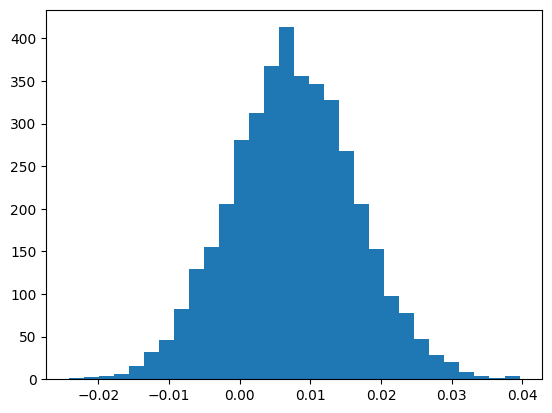

In [ ]:
plt.hist(f_medio, bins= 30)

In [ ]:
f_medio

array([0.00661631, 0.01402675, 0.01630035, ..., 0.00904526, 0.01145673,
       0.00396039])

### c)Graficar y dar percentiles de la distribución de $\beta_0 + \frac{1}{2} \beta_1$.

 Analizamos percentiles para ver la distribución de nuestros valores estimados y la incertidumbre.

In [ ]:
np.percentile(f_medio, [2.5, 25, 50, 75, 97.5])

array([-0.0099137 ,  0.0015823 ,  0.00743151,  0.01353448,  0.02522848])

In [ ]:
# Calcular percentiles
percentiles = np.percentile(f_medio, [2.5, 25, 50, 75, 97.5])
print("\nPercentiles de β₀ + 0.5β₁:")
print(f"2.5%: {percentiles[0]:.3f}")
print(f"25%:  {percentiles[1]:.3f}")
print(f"50%:  {percentiles[2]:.3f}")
print(f"75%:  {percentiles[3]:.3f}")
print(f"97.5%:{percentiles[4]:.3f}")


Percentiles de β₀ + 0.5β₁:
2.5%: -0.010
25%:  0.002
50%:  0.007
75%:  0.014
97.5%:0.025


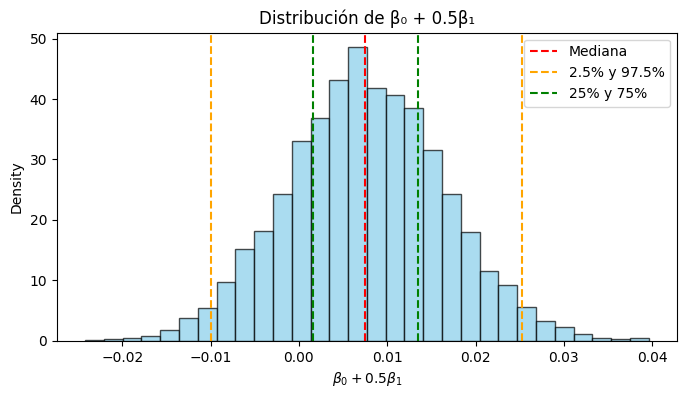

In [ ]:
# Asegurarse de que f_medio es un array unidimensional
f_medio = np.array(f_medio).flatten()

# Graficar la distribución de β₀ + 0.5β₁
plt.figure(figsize=(8, 4))
plt.hist(f_medio, bins=30, density=True, color="skyblue", alpha=0.7, edgecolor="black")
plt.axvline(percentiles[2], color="red", linestyle="--", label="Mediana")
plt.axvline(percentiles[0], color="orange", linestyle="--", label="2.5% y 97.5%")
plt.axvline(percentiles[4], color="orange", linestyle="--")
plt.axvline(percentiles[1], color="green", linestyle="--", label="25% y 75%")
plt.axvline(percentiles[3], color="green", linestyle="--")
plt.xlabel(r"$\beta_0 + 0.5 \beta_1$")
plt.ylabel("Density")
plt.title("Distribución de β₀ + 0.5β₁")
plt.legend()
plt.show()

## Ejercicio 7:

En el ajuste lineal del problema 5 graficar los datos sintéticos generados, el 90% HDI de 𝛽0 + 𝛽1𝑥 para cada valor de 𝑥, y el el 90% HDI para las estimaciones de 𝑦.

In [ ]:
x_pred = np.linspace(0, 1, 100)

0.5

In [ ]:
posterior_samples = trace.posterior
beta0_samples = posterior_samples['beta0'].values.flatten()
beta1_samples = posterior_samples['beta1'].values.flatten()
sigma_samples = posterior_samples['sigma'].values.flatten()

In [ ]:
y_pred_samples = np.zeros((len(beta0_samples), len(x_pred)))
y_obs_samples = np.zeros((len(beta0_samples), len(x_pred)))

for i in range(len(beta0_samples)):
    # mu = (β₀ + β₁x)
    y_pred_samples[i] = beta0_samples[i] + beta1_samples[i] * x_pred
    # y ∼ N(mu, sigma)
    y_obs_samples[i] = np.random.normal(y_pred_samples[i], sigma_samples[i], len(x_pred))

<ipython-input-86-d802df99ac7c>:2: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  y_pred_hdi = az.hdi(y_pred_samples, hdi_prob=0.9) # HDI para la línea de regresión
<ipython-input-86-d802df99ac7c>:3: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  y_obs_hdi = az.hdi(y_obs_samples, hdi_prob=0.9) # HDI para las observaciones


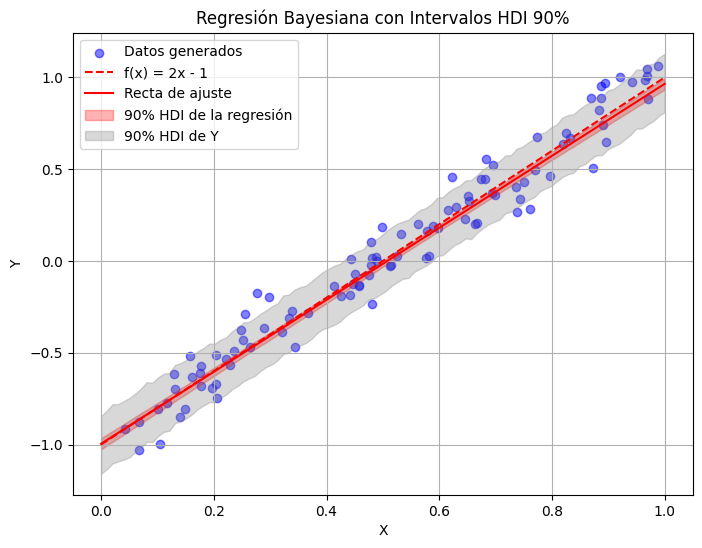

In [ ]:
# calcular HDI
y_pred_hdi = az.hdi(y_pred_samples, hdi_prob=0.9) # HDI para la línea de regresión
y_obs_hdi = az.hdi(y_obs_samples, hdi_prob=0.9) # HDI para las observaciones

plt.figure(figsize=(8, 6))
plt.scatter(X, Y, alpha=0.5, label='Datos generados', color="blue")
plt.plot(x_pred, 2 * x_pred - 1, 'r--', label='f(x) = 2x - 1')

plt.plot(x_pred, np.mean(y_pred_samples, axis=0), color="red", label="Recta de ajuste")
plt.fill_between(x_pred, y_pred_hdi[:, 0], y_pred_hdi[:, 1], color="red", alpha=0.3, label="90% HDI de la regresión")


# HDI 90% para las predicciones
plt.fill_between(x_pred,y_obs_hdi[:, 0],y_obs_hdi[:, 1], color="gray", alpha=0.3, label="90% HDI de Y")

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Regresión Bayesiana con Intervalos HDI 90%')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
summary = az.summary(trace, hdi_prob=0.9)
print("\nEstadísticas resumen (HDI 90%):")
summary


Estadísticas resumen (HDI 90%):


,mean,sd,hdi_5%,hdi_95%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta0,-0.996,0.019,-1.026,-0.965,0.000,0.000,1660.0,1967.0,1.0
beta1,1.961,0.032,1.913,2.016,0.001,0.001,1582.0,1822.0,1.0
sigma,0.096,0.007,0.085,0.107,0.000,0.000,2398.0,2239.0,1.0
